<a href="https://colab.research.google.com/github/Bharathi-S11/FibroTrack-AI/blob/main/FibroTrack_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 1. IMPORT **LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

2. LOAD DATA


In [ ]:
data = pd.read_csv("indian_liver_patient.csv")

In [ ]:
print("Initial Data:")
data.head()

Initial Data:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


3. DATA **CLEANING**

In [ ]:
# Rename columns (clean names)
data.columns = [
    'Age','Gender','Total_Bilirubin','Direct_Bilirubin',
    'Alkaline_Phosphatase','AST','ALT',
    'Total_Proteins','Albumin','A_G_Ratio','Dataset'
]

In [ ]:
# Handle missing values
data['A_G_Ratio'].fillna(data['A_G_Ratio'].median(), inplace=True)

In [ ]:
# Encode Gender
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])  # Male=1, Female=0

In [ ]:
# Drop original target (we create our own)
data = data.drop('Dataset', axis=1)

4. STAGE CREATION **(F0–F4)**

In [ ]:
def assign_stage(row):
    score = 0

    if row['Total_Bilirubin'] > 1.2:
        score += 1
    if row['ALT'] > 40:
        score += 1
    if row['AST'] > 40:
        score += 1
    if row['Albumin'] < 3.5:
        score += 1

    if score == 0:
        return 0
    elif score == 1:
        return 1
    elif score == 2:
        return 2
    elif score == 3:
        return 3
    else:
        return 4

data['Stage'] = data.apply(assign_stage, axis=1)

print("\nStage Distribution:")
print(data['Stage'].value_counts())


Stage Distribution:
Stage
1    162
3    122
4    115
0     93
2     91
Name: count, dtype: int64


5. **VISUALIZATION**

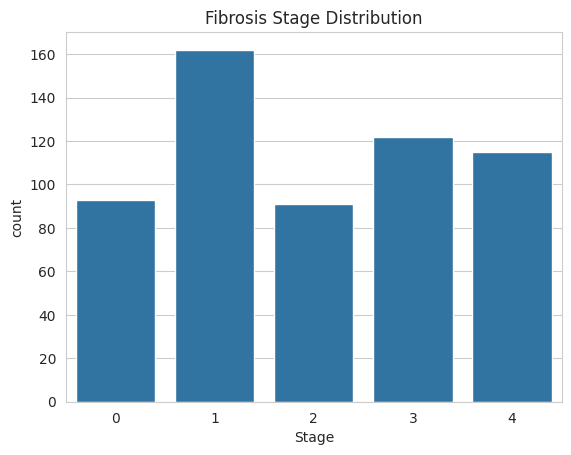

In [ ]:
plt.figure()
sns.countplot(x='Stage', data=data)
plt.title("Fibrosis Stage Distribution")
plt.show()

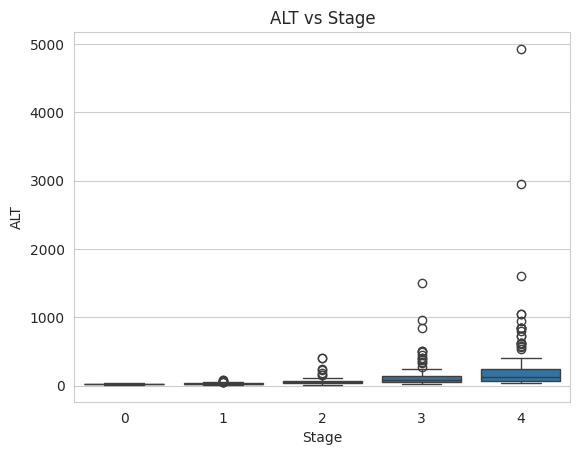

In [ ]:
# Enzyme vs stage
plt.figure()
sns.boxplot(x='Stage', y='ALT', data=data)
plt.title("ALT vs Stage")
plt.show()

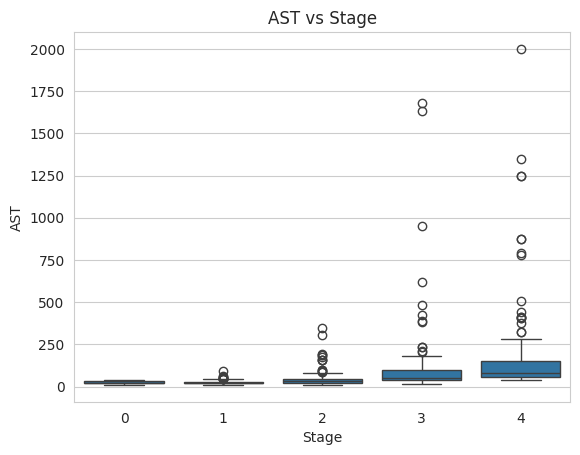

In [ ]:
plt.figure()
sns.boxplot(x='Stage', y='AST', data=data)
plt.title("AST vs Stage")
plt.show()

6. **PREPARE DATA FOR ML**

In [ ]:
X = data.drop('Stage', axis=1)
y = data['Stage']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

7. MODEL 1 — **LOGISTIC REGRESSION**

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))



--- Logistic Regression ---
Accuracy: 0.5384615384615384


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.47      0.50      0.49        18
           1       0.71      0.76      0.74        42
           2       0.13      0.22      0.17         9
           3       0.39      0.27      0.32        26
           4       0.65      0.59      0.62        22

    accuracy                           0.54       117
   macro avg       0.47      0.47      0.47       117
weighted avg       0.55      0.54      0.54       117



8. MODEL 2 — **RANDOM FOREST**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
print("\n--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


--- Random Forest ---
Accuracy: 0.9743589743589743


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.98      0.99        42
           2       0.75      1.00      0.86         9
           3       1.00      0.92      0.96        26
           4       1.00      1.00      1.00        22

    accuracy                           0.97       117
   macro avg       0.95      0.98      0.96       117
weighted avg       0.98      0.97      0.98       117



 9. **CONFUSION MATRIX**

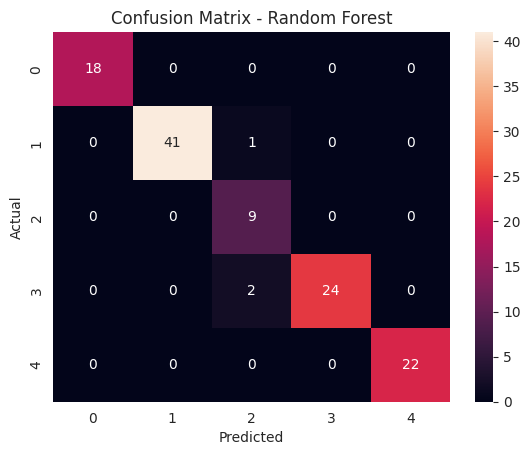

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

10. **FEATURE IMPORTANCE**

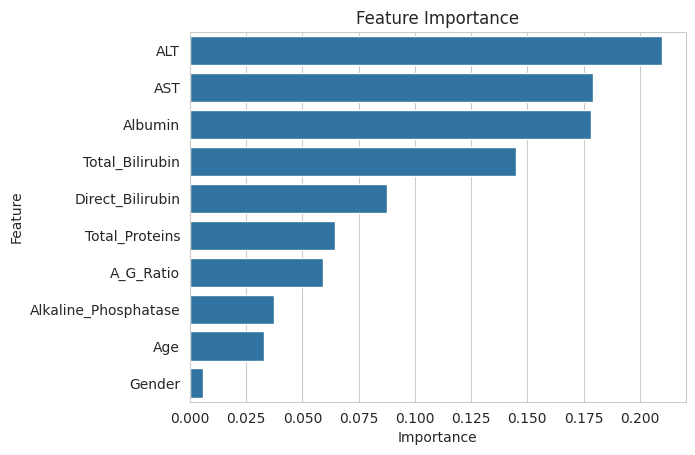

In [ ]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

In [ ]:
print("\nTop Features:")
print(feat_df.head())


Top Features:
            Feature  Importance
6               ALT    0.210021
5               AST    0.179059
8           Albumin    0.178254
2   Total_Bilirubin    0.145187
3  Direct_Bilirubin    0.087692


# **SHAP**

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(rf)

# Convert X_test back to DataFrame (important)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# SHAP values
shap_values = explainer.shap_values(X_test_df)

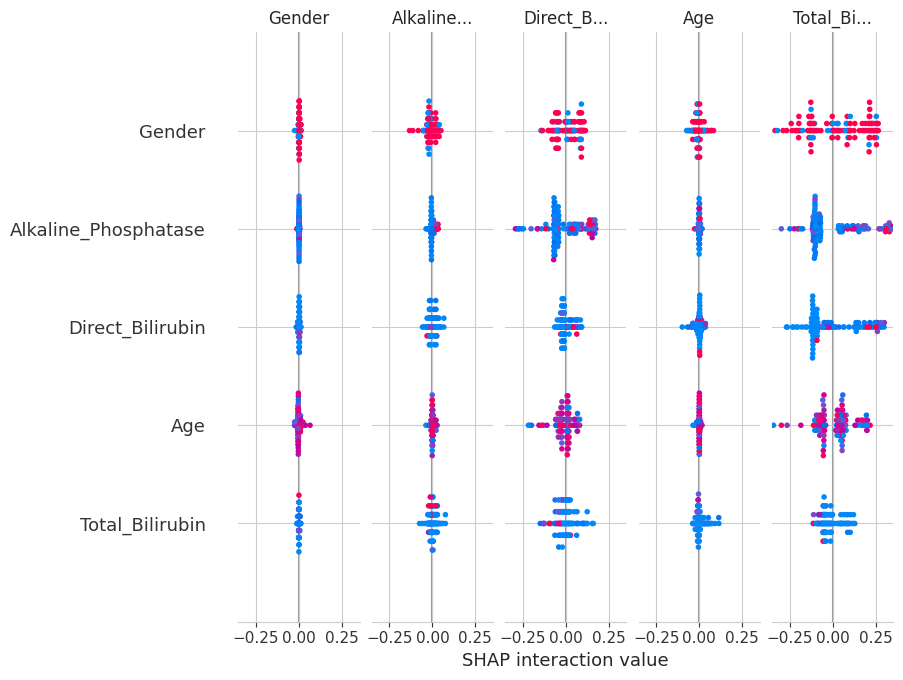

In [ ]:
shap.summary_plot(shap_values, X_test_df)

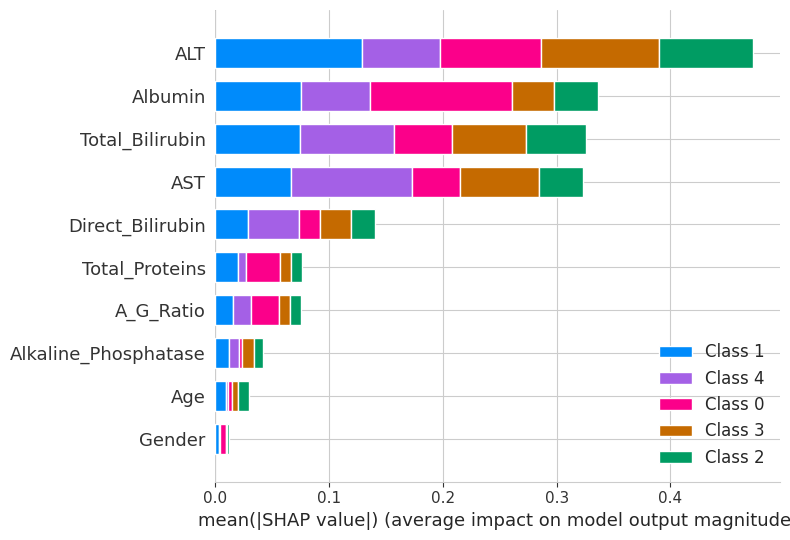

In [ ]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

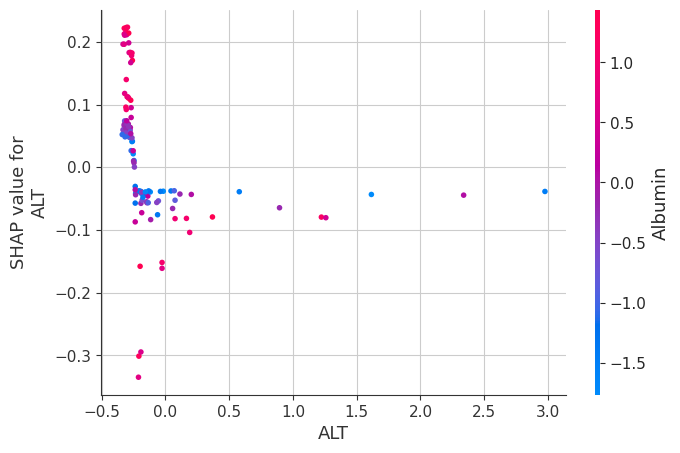

In [ ]:
shap.dependence_plot("ALT", shap_values[:, :, 0], X_test_df)

In [ ]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>